In [190]:
import pandas as pd
import numpy as np
import missingno as msno
from scipy.stats import norm

# Data ingestion, cleaning and merging

In [191]:
dataset_food_inflation_rate = pd.read_csv('./data/food_inflation_rate.csv')

In [192]:
dataset_food_inflation_rate.head()

,Domain Code,Domain,Area Code (M49),Area,Year Code,Year,Item Code,Item,Months Code,Months,Element Code,Element,Unit,Value,Flag,Flag Description,Note
0,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7001,January,6121,Value,%,2.607987,E,Estimated value,NaN
1,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7002,February,6121,Value,%,3.896104,E,Estimated value,NaN
2,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7003,March,6121,Value,%,2.967121,E,Estimated value,NaN
3,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7004,April,6121,Value,%,2.149682,E,Estimated value,NaN
4,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7005,May,6121,Value,%,3.559871,E,Estimated value,NaN


In [193]:
dataset_food_inflation_rate = dataset_food_inflation_rate[['Area', 'Year', 'Months', 'Value']]

In [194]:
dataset_food_inflation_rate = dataset_food_inflation_rate.rename(columns = {'Value': 'Food Inflation Rate'})

In [195]:
dataset_food_inflation_rate.head()

,Area,Year,Months,Food Inflation Rate
0,Åland Islands,2012,January,2.607987
1,Åland Islands,2012,February,3.896104
2,Åland Islands,2012,March,2.967121
3,Åland Islands,2012,April,2.149682
4,Åland Islands,2012,May,3.559871


In [196]:
dataset_food_inflation_rate = dataset_food_inflation_rate.groupby(['Area', 'Year'], as_index=False)['Food Inflation Rate'].mean()

In [197]:
dataset_food_inflation_rate.head()

,Area,Year,Food Inflation Rate
0,Albania,2012,2.404087
1,Albania,2013,4.214607
2,Albania,2014,2.212385
3,Albania,2015,4.294233
4,Albania,2016,3.254620


In [198]:
dataset_food_inflation_rate.isnull().sum()

Area                   0
Year                   0
Food Inflation Rate    0
dtype: int64

In [199]:
dataset_raw_gdp = pd.read_csv('./data/raw_gdp.csv')

In [200]:
dataset_raw_gdp.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2012,2012,million USD,12319.779604,X,Figure from international organizations,NaN
1,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2013,2013,million USD,12776.280738,X,Figure from international organizations,NaN
2,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2014,2014,million USD,13228.240079,X,Figure from international organizations,NaN
3,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2015,2015,million USD,11386.924853,X,Figure from international organizations,NaN
4,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2016,2016,million USD,11861.356451,X,Figure from international organizations,NaN


In [201]:
dataset_raw_gdp = dataset_raw_gdp[['Area', 'Year', 'Value']]

In [202]:
dataset_raw_gdp = dataset_raw_gdp.rename(columns = {'Value': 'Raw GDP'})

In [203]:
dataset_raw_gdp.head()

,Area,Year,Raw GDP
0,Albania,2012,12319.779604
1,Albania,2013,12776.280738
2,Albania,2014,13228.240079
3,Albania,2015,11386.924853
4,Albania,2016,11861.356451


In [204]:
dataset_raw_gdp.isnull().sum()

Area       0
Year       0
Raw GDP    0
dtype: int64

In [205]:
dataset_gdp_growth_rate = pd.read_csv('./data/gdp_growth_rate.csv')

In [206]:
dataset_gdp_growth_rate.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2012,2012,%,-4.430218,X,Figure from international organizations,NaN
1,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2013,2013,%,3.705432,X,Figure from international organizations,NaN
2,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2014,2014,%,3.537487,X,Figure from international organizations,NaN
3,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2015,2015,%,-13.919579,X,Figure from international organizations,NaN
4,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2016,2016,%,4.166459,X,Figure from international organizations,NaN


In [207]:
dataset_gdp_growth_rate.isnull().sum()

Domain Code           0
Domain                0
Area Code (M49)       0
Area                  0
Element Code          0
Element               0
Item Code             0
Item                  0
Year Code             0
Year                  0
Unit                  0
Value                 0
Flag                  0
Flag Description      0
Note                515
dtype: int64

In [208]:
dataset_gdp_growth_rate = dataset_gdp_growth_rate[['Area', 'Year', 'Value']]

In [209]:
dataset_gdp_growth_rate = dataset_gdp_growth_rate.rename(columns = {"Value": "GDP Growth Rate"})

In [210]:
dataset_gdp_growth_rate.head()

,Area,Year,GDP Growth Rate
0,Albania,2012,-4.430218
1,Albania,2013,3.705432
2,Albania,2014,3.537487
3,Albania,2015,-13.919579
4,Albania,2016,4.166459


In [211]:
dataset_gdp_growth_rate.isnull().sum()

Area               0
Year               0
GDP Growth Rate    0
dtype: int64

In [212]:
dataset_producer_prices = pd.read_csv('./data/producer_prices.csv')

In [213]:
dataset_producer_prices = dataset_producer_prices[['Area', 'Year', 'Item', 'Value']]

In [214]:
dataset_producer_prices = dataset_producer_prices.rename(columns={"Value": "Item Price Per Tonne"})

In [215]:
dataset_producer_prices.head()

,Area,Year,Item,Item Price Per Tonne
0,Albania,2012,Apples,369.7
1,Albania,2013,Apples,492.1
2,Albania,2014,Apples,474.8
3,Albania,2015,Apples,389.0
4,Albania,2016,Apples,381.3


In [216]:
dataset_producer_prices.isnull().sum()

Area                    0
Year                    0
Item                    0
Item Price Per Tonne    0
dtype: int64

In [217]:
dataset_overall_inflation = pd.read_excel('./data/overall_inflation.xlsx')

In [218]:
dataset_overall_inflation.head()

,Data extracted on 22/07/2024 23:21:37 from [ESTAT],Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,Dataset:,HICP - inflation rate [tec00118],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last updated:,17/07/2024 11:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Time frequency,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unit of measure,NaN,Annual average rate of change,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [219]:
dataset_overall_inflation.isnull().sum()

Data extracted on 22/07/2024 23:21:37 from [ESTAT]     3
Unnamed: 1                                             9
Unnamed: 2                                            49
Unnamed: 3                                            13
Unnamed: 4                                            52
Unnamed: 5                                            13
Unnamed: 6                                            52
Unnamed: 7                                            13
Unnamed: 8                                            52
Unnamed: 9                                            13
Unnamed: 10                                           51
Unnamed: 11                                           13
Unnamed: 12                                           49
Unnamed: 13                                           13
Unnamed: 14                                           49
Unnamed: 15                                           13
Unnamed: 16                                           49
Unnamed: 17                    

In [220]:
columns_to_drop = [f'Unnamed: {i}' for i in range(2, 25) if i % 2 == 0]
columns_to_drop

['Unnamed: 2',
 'Unnamed: 4',
 'Unnamed: 6',
 'Unnamed: 8',
 'Unnamed: 10',
 'Unnamed: 12',
 'Unnamed: 14',
 'Unnamed: 16',
 'Unnamed: 18',
 'Unnamed: 20',
 'Unnamed: 22',
 'Unnamed: 24']

In [221]:
dataset_overall_inflation = dataset_overall_inflation[12:51]

In [222]:
dataset_overall_inflation = dataset_overall_inflation.drop(columns=columns_to_drop)

In [223]:
columns_to_stay = [f'Unnamed: {i}' for i in range(1, 25) if i % 2 == 1]

In [224]:
dict_rename_columns = {}

In [225]:
for prev_name, year in zip(columns_to_stay, range(2012, 2024)):
    dict_rename_columns[prev_name] = year

In [226]:
dict_rename_columns

{'Unnamed: 1': 2012,
 'Unnamed: 3': 2013,
 'Unnamed: 5': 2014,
 'Unnamed: 7': 2015,
 'Unnamed: 9': 2016,
 'Unnamed: 11': 2017,
 'Unnamed: 13': 2018,
 'Unnamed: 15': 2019,
 'Unnamed: 17': 2020,
 'Unnamed: 19': 2021,
 'Unnamed: 21': 2022,
 'Unnamed: 23': 2023}

In [227]:
dict_rename_columns['Data extracted on 22/07/2024 23:21:37 from [ESTAT]'] = 'Area'

In [228]:
dataset_overall_inflation = dataset_overall_inflation.rename(columns=dict_rename_columns)

In [229]:
dataset_overall_inflation

,Area,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
12,Belgium,2.6,1.2,0.5,0.6,1.8,2.2,2.3,1.2,0.4,3.2,10.3,2.3
13,Bulgaria,2.4,0.4,-1.6,-1.1,-1.3,1.2,2.6,2.5,1.2,2.8,13,8.6
14,Czechia,3.5,1.4,0.4,0.3,0.6,2.4,2,2.6,3.3,3.3,14.8,12
15,Denmark,2.4,0.5,0.4,0.2,0,1.1,0.7,0.7,0.3,1.9,8.5,3.4
16,Germany,2.2,1.6,0.8,0.7,0.4,1.7,1.9,1.4,0.4,3.2,8.7,6
17,Estonia,4.2,3.2,0.5,0.1,0.8,3.7,3.4,2.3,-0.6,4.5,19.4,9.1
18,Ireland,1.9,0.5,0.3,0,-0.2,0.3,0.7,0.9,-0.5,2.4,8.1,5.2
19,Greece,1,-0.9,-1.4,-1.1,0,1.1,0.8,0.5,-1.3,0.6,9.3,4.2
20,Spain,2.4,1.5,-0.2,-0.6,-0.3,2,1.7,0.8,-0.3,3,8.3,3.4
21,France,2.2,1,0.6,0.1,0.3,1.2,2.1,1.3,0.5,2.1,5.9,5.7


In [230]:
dataset_overall_inflation = dataset_overall_inflation.melt(id_vars=['Area'], var_name='Year', value_name='Overall Inflation Rate')

In [231]:
dataset_overall_inflation = dataset_overall_inflation[dataset_overall_inflation['Area']!='Liechtenstein']

In [232]:
dataset_overall_inflation = dataset_overall_inflation.replace(to_replace=":", value=np.nan)

In [233]:
dataset_overall_inflation = dataset_overall_inflation.sort_values(by=['Area', 'Year'])

In [234]:
df = dataset_overall_inflation.copy()

In [235]:
dataset_overall_inflation.head()

,Area,Year,Overall Inflation Rate
34,Albania,2012,NaN
73,Albania,2013,NaN
112,Albania,2014,NaN
151,Albania,2015,NaN
190,Albania,2016,NaN


In [236]:
dataset_overall_inflation.isnull().sum()

Area                       0
Year                       0
Overall Inflation Rate    18
dtype: int64

<Axes: >

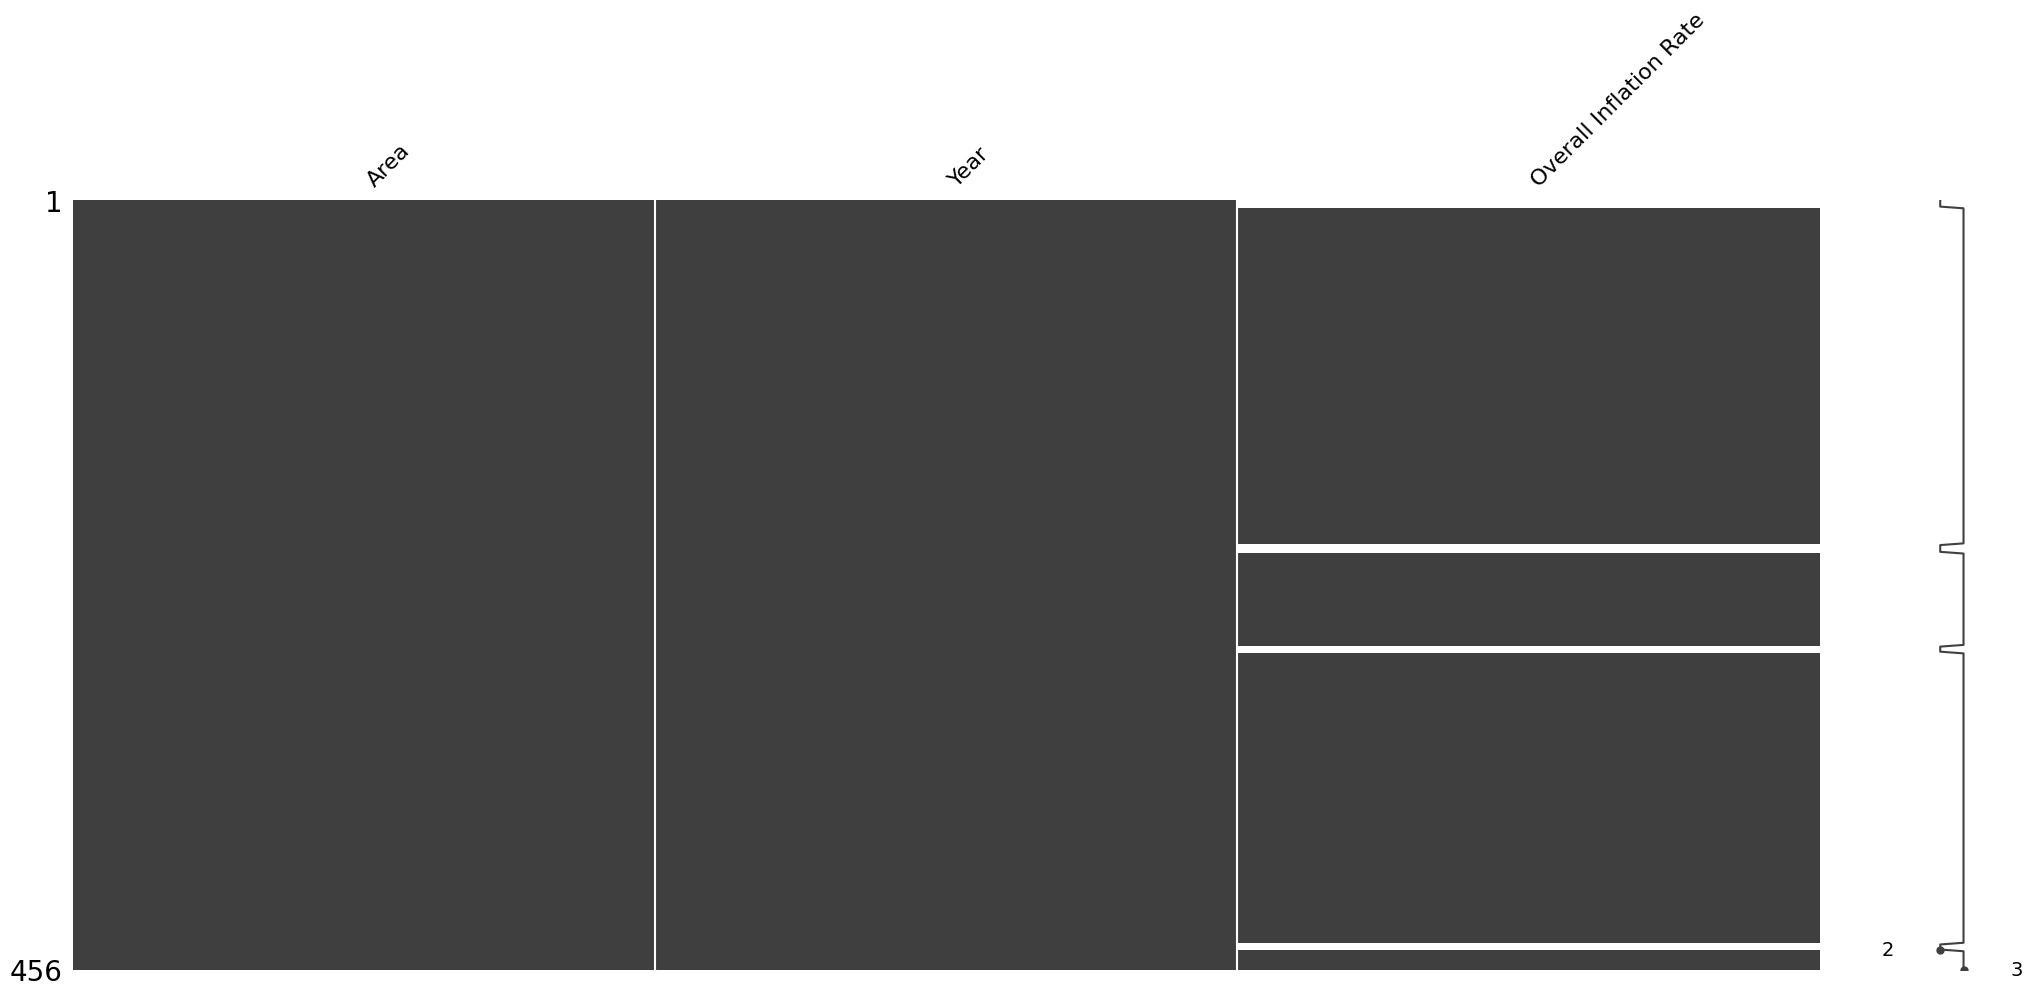

In [237]:
msno.matrix(df) 

In [238]:
tmp = dataset_overall_inflation.groupby('Area')['Overall Inflation Rate'].apply(lambda group: group.bfill()).reset_index()

In [239]:
tmp = tmp.rename(columns={'level_1': 'index'})

In [240]:
tmp = tmp.set_index('index')

In [241]:
dataset_overall_inflation['Overall Inflation Rate'] = tmp['Overall Inflation Rate']

In [242]:
tmp = dataset_overall_inflation.groupby('Area')['Overall Inflation Rate'].apply(lambda group: group.ffill()).reset_index()

In [243]:
tmp = tmp.rename(columns={'level_1': 'index'})

In [244]:
tmp = tmp.set_index('index')

In [245]:
dataset_overall_inflation['Overall Inflation Rate'] = tmp['Overall Inflation Rate']

In [246]:
dataset_overall_inflation

,Area,Year,Overall Inflation Rate
34,Albania,2012,3.2
73,Albania,2013,3.2
112,Albania,2014,3.2
151,Albania,2015,3.2
190,Albania,2016,3.2
...,...,...,...
311,United States,2019,1.4
350,United States,2020,0.8
389,United States,2021,5.3
428,United States,2022,8.7


In [247]:
data = pd.merge(dataset_food_inflation_rate, dataset_raw_gdp, on=['Area', 'Year'], how='inner')

In [248]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP
0,Albania,2012,2.404087,12319.779604
1,Albania,2013,4.214607,12776.280738
2,Albania,2014,2.212385,13228.240079
3,Albania,2015,4.294233,11386.924853
4,Albania,2016,3.254620,11861.356451


In [249]:
data = pd.merge(data, dataset_gdp_growth_rate, on=['Area', 'Year'], how='inner')

In [250]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate
0,Albania,2012,2.404087,12319.779604,-4.430218
1,Albania,2013,4.214607,12776.280738,3.705432
2,Albania,2014,2.212385,13228.240079,3.537487
3,Albania,2015,4.294233,11386.924853,-13.919579
4,Albania,2016,3.254620,11861.356451,4.166459


In [251]:
data = pd.merge(data, dataset_producer_prices, on=['Area', 'Year'], how='inner')

In [252]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.2
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4


In [253]:
dataset_overall_inflation['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany',
       'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo*',
       'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Montenegro',
       'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal',
       'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland', 'Türkiye', 'United Kingdom', 'United States'],
      dtype=object)

In [254]:
data = pd.merge(data, dataset_overall_inflation, on=['Area', 'Year'], how='inner')

In [255]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.2,3.2
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2


In [256]:
annual_growth = pd.read_csv('./data/import_export_annual_growth_data.csv')
annual_growth.columns = annual_growth.columns.str.replace(r"\s*\[YR\d{4}\]", "", regex=True)
annual_growth = annual_growth.drop(columns=["Country Code", "Series Code"])
annual_growth.rename(columns={'Country Name': 'Area'}, inplace=True)
annual_growth = annual_growth[0:64]

In [257]:
annual_growth['Area'].unique()

array(['Albania', 'Montenegro', 'Spain', 'Greece', 'Portugal',
       'Switzerland', 'Hungary', 'Germany', 'Croatia', 'Austria',
       'Bulgaria', 'Latvia', 'Romania', 'Poland', 'Slovakia', 'Czechia',
       'Norway', 'France', 'Slovenia', 'Belgium', 'Lithuania', 'Serbia',
       'North Macedonia', 'Denmark', 'Malta', 'Luxembourg', 'Estonia',
       'Finland', 'Sweden', 'Italy', 'Iceland', 'Ireland'], dtype=object)

In [258]:
annual_growth_import = annual_growth[annual_growth['Series Name'] == 'Imports of goods and services (annual % growth)'].drop(columns=["Series Name"])

annual_growth_export = annual_growth[annual_growth['Series Name'] == 'Exports of goods and services (annual % growth)'].drop(columns=["Series Name"])

In [259]:
annual_growth_import = annual_growth_import.melt(id_vars=['Area'], var_name='Year', value_name='Import Rate')

annual_growth_export = annual_growth_export.melt(id_vars=['Area'], var_name='Year', value_name='Export Rate')

In [260]:
annual_growth_import['Year'] = annual_growth_import['Year'].astype(int)

annual_growth_export['Year'] = annual_growth_export['Year'].astype(int)

In [261]:
data = pd.merge(data, annual_growth_import, on=['Area', 'Year'], how='inner')

data = pd.merge(data, annual_growth_export, on=['Area', 'Year'], how='inner')

In [262]:
unemployment_rate = pd.read_csv('./data/unemployment_rate_data.csv', delimiter=';')
unemployment_rate.rename(columns={'Country Name': 'Area'}, inplace=True)

In [263]:
unemployment_rate = unemployment_rate.melt(id_vars=['Area'], var_name='Year', value_name='Unemployment Rate')

In [264]:
unemployment_rate['Year'] = unemployment_rate['Year'].astype(int)

In [265]:
unemployment_rate.head()

,Area,Year,Unemployment Rate
0,Aruba,2012,NaN
1,Africa Eastern and Southern,2012,7.181608
2,Afghanistan,2012,7.856000
3,Africa Western and Central,2012,3.982163
4,Angola,2012,16.562000


In [266]:
data = pd.merge(data, unemployment_rate, on=['Area', 'Year'], how='inner')

In [267]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2,-6.930669,0.293588,13.376
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2,-6.930669,0.293588,13.376
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2,-6.930669,0.293588,13.376
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.2,3.2,-6.930669,0.293588,13.376
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2,-6.930669,0.293588,13.376


In [268]:
official_exchange_rate = pd.read_csv('./data/official_exchange_rate_(local_currency_per_us_dollar).csv', delimiter=',')
official_exchange_rate.rename(columns={'Country Name': 'Area'}, inplace=True)

In [269]:
official_exchange_rate = official_exchange_rate.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code'])

In [270]:
official_exchange_rate.head()

,Area,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.790000,1.790000,1.790000,1.790000,1.790000,1.790000,1.790000,1.790000,1.79000,NaN
1,Africa Eastern and Southern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1.719656e+01,1.719656e+01,1.719656e+01,3.510964e+01,3.869226e+01,3.869226e+01,3.869226e+01,3.869226e+01,3.869226e+01,...,67.866086,68.026904,72.083247,77.737949,76.813536,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,2.866844e-08,2.873486e-08,2.867844e-08,2.875203e-08,2.881978e-08,2.877853e-08,2.882386e-08,2.884161e-08,2.872761e-08,...,163.656434,165.915951,252.855748,364.825805,578.258780,631.441956,460.567512,685.020238,869.84619,NaN


In [271]:
official_exchange_rate = official_exchange_rate.melt(id_vars=['Area'], var_name='Year', value_name='Official Exchange Rate')

In [272]:
official_exchange_rate['Year_numeric'] = pd.to_numeric(official_exchange_rate['Year'], errors='coerce')
official_exchange_rate = official_exchange_rate[official_exchange_rate['Year_numeric'].notna()]
official_exchange_rate['Year'] = official_exchange_rate['Year_numeric'].astype(int)
official_exchange_rate = official_exchange_rate.drop(columns='Year_numeric')

In [273]:
official_exchange_rate.head()

,Area,Year,Official Exchange Rate
0,Aruba,1960,NaN
1,Africa Eastern and Southern,1960,NaN
2,Afghanistan,1960,1.719656e+01
3,Africa Western and Central,1960,NaN
4,Angola,1960,2.866844e-08


In [274]:
data = pd.merge(data, official_exchange_rate, on=['Area', 'Year'], how='inner')

In [275]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate,Official Exchange Rate
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2,-6.930669,0.293588,13.376,108.184167
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2,-6.930669,0.293588,13.376,108.184167
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2,-6.930669,0.293588,13.376,108.184167
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.2,3.2,-6.930669,0.293588,13.376,108.184167
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2,-6.930669,0.293588,13.376,108.184167


In [276]:
data['Area'] = data['Area'].replace('North Macedonia', 'Macedonia')

In [277]:
data.isnull().sum()

Area                      0
Year                      0
Food Inflation Rate       0
Raw GDP                   0
GDP Growth Rate           0
Item                      0
Item Price Per Tonne      0
Overall Inflation Rate    0
Import Rate               0
Export Rate               0
Unemployment Rate         0
Official Exchange Rate    0
dtype: int64

In [278]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'Macedonia', 'Norway', 'Poland', 'Portugal',
       'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland'], dtype=object)

In [279]:
data

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate,Official Exchange Rate
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2,-6.930669,0.293588,13.376,108.184167
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2,-6.930669,0.293588,13.376,108.184167
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2,-6.930669,0.293588,13.376,108.184167
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.2,3.2,-6.930669,0.293588,13.376,108.184167
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2,-6.930669,0.293588,13.376,108.184167
...,...,...,...,...,...,...,...,...,...,...,...,...
15644,Switzerland,2022,1.661019,818426.550206,0.616880,Tomatoes,3407.9,2.7,5.788234,6.103811,4.122,0.954832
15645,Switzerland,2022,1.661019,818426.550206,0.616880,Triticale,362.4,2.7,5.788234,6.103811,4.122,0.954832
15646,Switzerland,2022,1.661019,818426.550206,0.616880,Unmanufactured tobacco,16495.0,2.7,5.788234,6.103811,4.122,0.954832
15647,Switzerland,2022,1.661019,818426.550206,0.616880,"Walnuts, in shell",3498.0,2.7,5.788234,6.103811,4.122,0.954832


In [280]:
data['Difference of inflation'] = data['Food Inflation Rate'] - data['Overall Inflation Rate']

In [281]:
mean_value = data['Difference of inflation'].mean()
std_dev = data['Difference of inflation'].std()
mean_value, std_dev

(0.6515898678563061, 1.8824104304769325)

In [282]:
alpha = 0.05

data['z_score'] = (data['Difference of inflation'] - mean_value) / std_dev
z_critical = norm.ppf(1 - alpha)

data['label'] = (data['z_score'] > z_critical).astype(int)

In [283]:
data.drop(columns=['Difference of inflation', 'z_score'], inplace=True)

In [284]:
len(data[data['label'] == 0]), len(data[data['label'] == 1])

(14845, 804)

In [285]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate,Official Exchange Rate,label
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2,-6.930669,0.293588,13.376,108.184167,0
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2,-6.930669,0.293588,13.376,108.184167,0
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2,-6.930669,0.293588,13.376,108.184167,0
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.2,3.2,-6.930669,0.293588,13.376,108.184167,0
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2,-6.930669,0.293588,13.376,108.184167,0


In [286]:
data.to_csv('./data/data.csv', index=False)